# Your Very First Machine Learning (ML) Model: Logistic Regression

Dataset: [College Student Placement Factors Dataset](https://www.kaggle.com/datasets/sahilislam007/college-student-placement-factors-dataset) (`data/college_student_placement_dataset.csv`)

In [3]:
# Install required packages into the current kernel
%pip install -q scikit-learn seaborn statsmodels matplotlib

from IPython.display import display

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import statsmodels.api as sm

sns.set(style="whitegrid")


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Constants

It is a good programming practice to use constants to avoid repetition errors and to save yourself the effort of retyping the expression by _centralizing_ semantically identical values.

`DATASET_PATH` identifies the path to the dataset being loaded and operated on. `RANDOM_STATE` makes otherwise random operations reproducible run after run. Keep whatever value you set it to unless you want slightly different results.

In [4]:
DATASET_PATH = 'data/college_student_placement_dataset.csv'
RANDOM_STATE = 45

## Preliminary Inspection

See what the raw file looks like!

In [6]:
# Look at the first 5 lines of theraw contents of the file first.
DATASET_PATH = "/Users/sebastianramos/CTP/ds-fall-2025-tue/Week-07-Classification/data/college_student_placement_dataset.csv"
with open(DATASET_PATH, 'r') as file:
    for line_number in range(5):
        if line := file.readline():
            print(line)
        else:
            break # Stop; there are less than 5 lines.


College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement

CLG0030,107,6.61,6.28,8,No,8,8,4,No

CLG0061,97,5.52,5.37,8,No,7,8,0,No

CLG0036,109,5.36,5.83,9,No,3,1,1,No

CLG0055,122,5.47,5.75,6,Yes,1,6,1,No



## Preliminary Load

Load the data. This is not the final form of the data which will be used, but it’s a `DataFrame` for further inspection so we can decide what to do with it next.

In [8]:
# Load the dataset into a pandas dataframe.
import pandas as pd

df = pd.read_csv(DATASET_PATH)
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


## Null Values Check
Inspect which varibles may be good / not good for using as features based on null values. 


In [9]:
# Identify which columns have null values. 
# Check for null values in each column and display them
null_counts = df.isnull().sum()
print("Null values in each column:\n", null_counts)

# Optionally, show columns that have any nulls
cols_with_nulls = null_counts[null_counts > 0]
if not cols_with_nulls.empty:
    print("\nColumns with null values:\n", cols_with_nulls)
else:
    print("\nNo columns with null values.")



Null values in each column:
 College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

No columns with null values.


## Duplicate Rows Check
If so, remove the duplicates.

In [11]:
# Check to see if our data has any duplicate rows.
# Find duplicate rows
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

# If duplicates exist, show them
if not duplicate_rows.empty:
    print("Duplicate rows:")
    print(duplicate_rows)

    # Remove duplicate rows (keep the first occurrence)
    df = df.drop_duplicates()
    print("Duplicates removed. New data shape:", df.shape)
else:
    print("No duplicate rows found.")



Number of duplicate rows: 0
No duplicate rows found.


Many clean… 😐

## Categorical Categories

What are the categories for the categorial-looking (i.e., non-numeric) columns?

In [12]:
# Identify columns with non-numeric (object or category) data types
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Display the unique categories for each categorical column
for col in cat_cols:
    print(f"Categories for '{col}': {df[col].unique()}")


Categories for 'College_ID': ['CLG0030' 'CLG0061' 'CLG0036' 'CLG0055' 'CLG0004' 'CLG0015' 'CLG0071'
 'CLG0096' 'CLG0097' 'CLG0057' 'CLG0063' 'CLG0077' 'CLG0064' 'CLG0017'
 'CLG0053' 'CLG0040' 'CLG0070' 'CLG0050' 'CLG0068' 'CLG0072' 'CLG0034'
 'CLG0087' 'CLG0073' 'CLG0024' 'CLG0008' 'CLG0025' 'CLG0018' 'CLG0014'
 'CLG0006' 'CLG0082' 'CLG0090' 'CLG0075' 'CLG0094' 'CLG0089' 'CLG0016'
 'CLG0076' 'CLG0047' 'CLG0054' 'CLG0058' 'CLG0100' 'CLG0046' 'CLG0001'
 'CLG0041' 'CLG0093' 'CLG0027' 'CLG0062' 'CLG0081' 'CLG0028' 'CLG0020'
 'CLG0051' 'CLG0069' 'CLG0088' 'CLG0038' 'CLG0029' 'CLG0035' 'CLG0019'
 'CLG0005' 'CLG0026' 'CLG0066' 'CLG0045' 'CLG0043' 'CLG0074' 'CLG0048'
 'CLG0012' 'CLG0099' 'CLG0011' 'CLG0091' 'CLG0083' 'CLG0080' 'CLG0044'
 'CLG0059' 'CLG0031' 'CLG0039' 'CLG0065' 'CLG0079' 'CLG0095' 'CLG0085'
 'CLG0033' 'CLG0007' 'CLG0037' 'CLG0032' 'CLG0049' 'CLG0056' 'CLG0084'
 'CLG0067' 'CLG0098' 'CLG0042' 'CLG0021' 'CLG0009' 'CLG0010' 'CLG0078'
 'CLG0013' 'CLG0003' 'CLG0092' 'CLG0086' 'CLG002

## Feature Engineering

Non-numeric columns containing `'Yes'` and `'No'` do not work with logistic regression. Binary categories can be converted an integral type (`int`) with a value of 0 or 1.

In [13]:

# Convert binary categorical columns ('Yes'/'No') to 0/1 for logistic regression compatibility
df['Internship_Experience'] = df['Internship_Experience'].map({'No': 0, 'Yes': 1})
df['Placement'] = df['Placement'].map({'No': 0, 'Yes': 1})
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0
1,CLG0061,97,5.52,5.37,8,0,7,8,0,0
2,CLG0036,109,5.36,5.83,9,0,3,1,1,0
3,CLG0055,122,5.47,5.75,6,1,1,6,1,0
4,CLG0004,96,7.91,7.69,7,0,8,10,2,0


❔ When should you use this versus using `pd.get_dummies`?
# 👉 Use direct mapping (like .map({'No': 0, 'Yes': 1})) when the categorical column has exactly two unique values
#    (i.e., a binary variable), and you want a single column (ideal for logistic regression and efficiency).
# 👉 Use pd.get_dummies when a column has more than two categories, or when you want to create multiple indicator variables
#    for all unique categories in the column (one-hot encoding). This is common for nominal variables with >2 values.


# Visualization with `sns.pairplot`

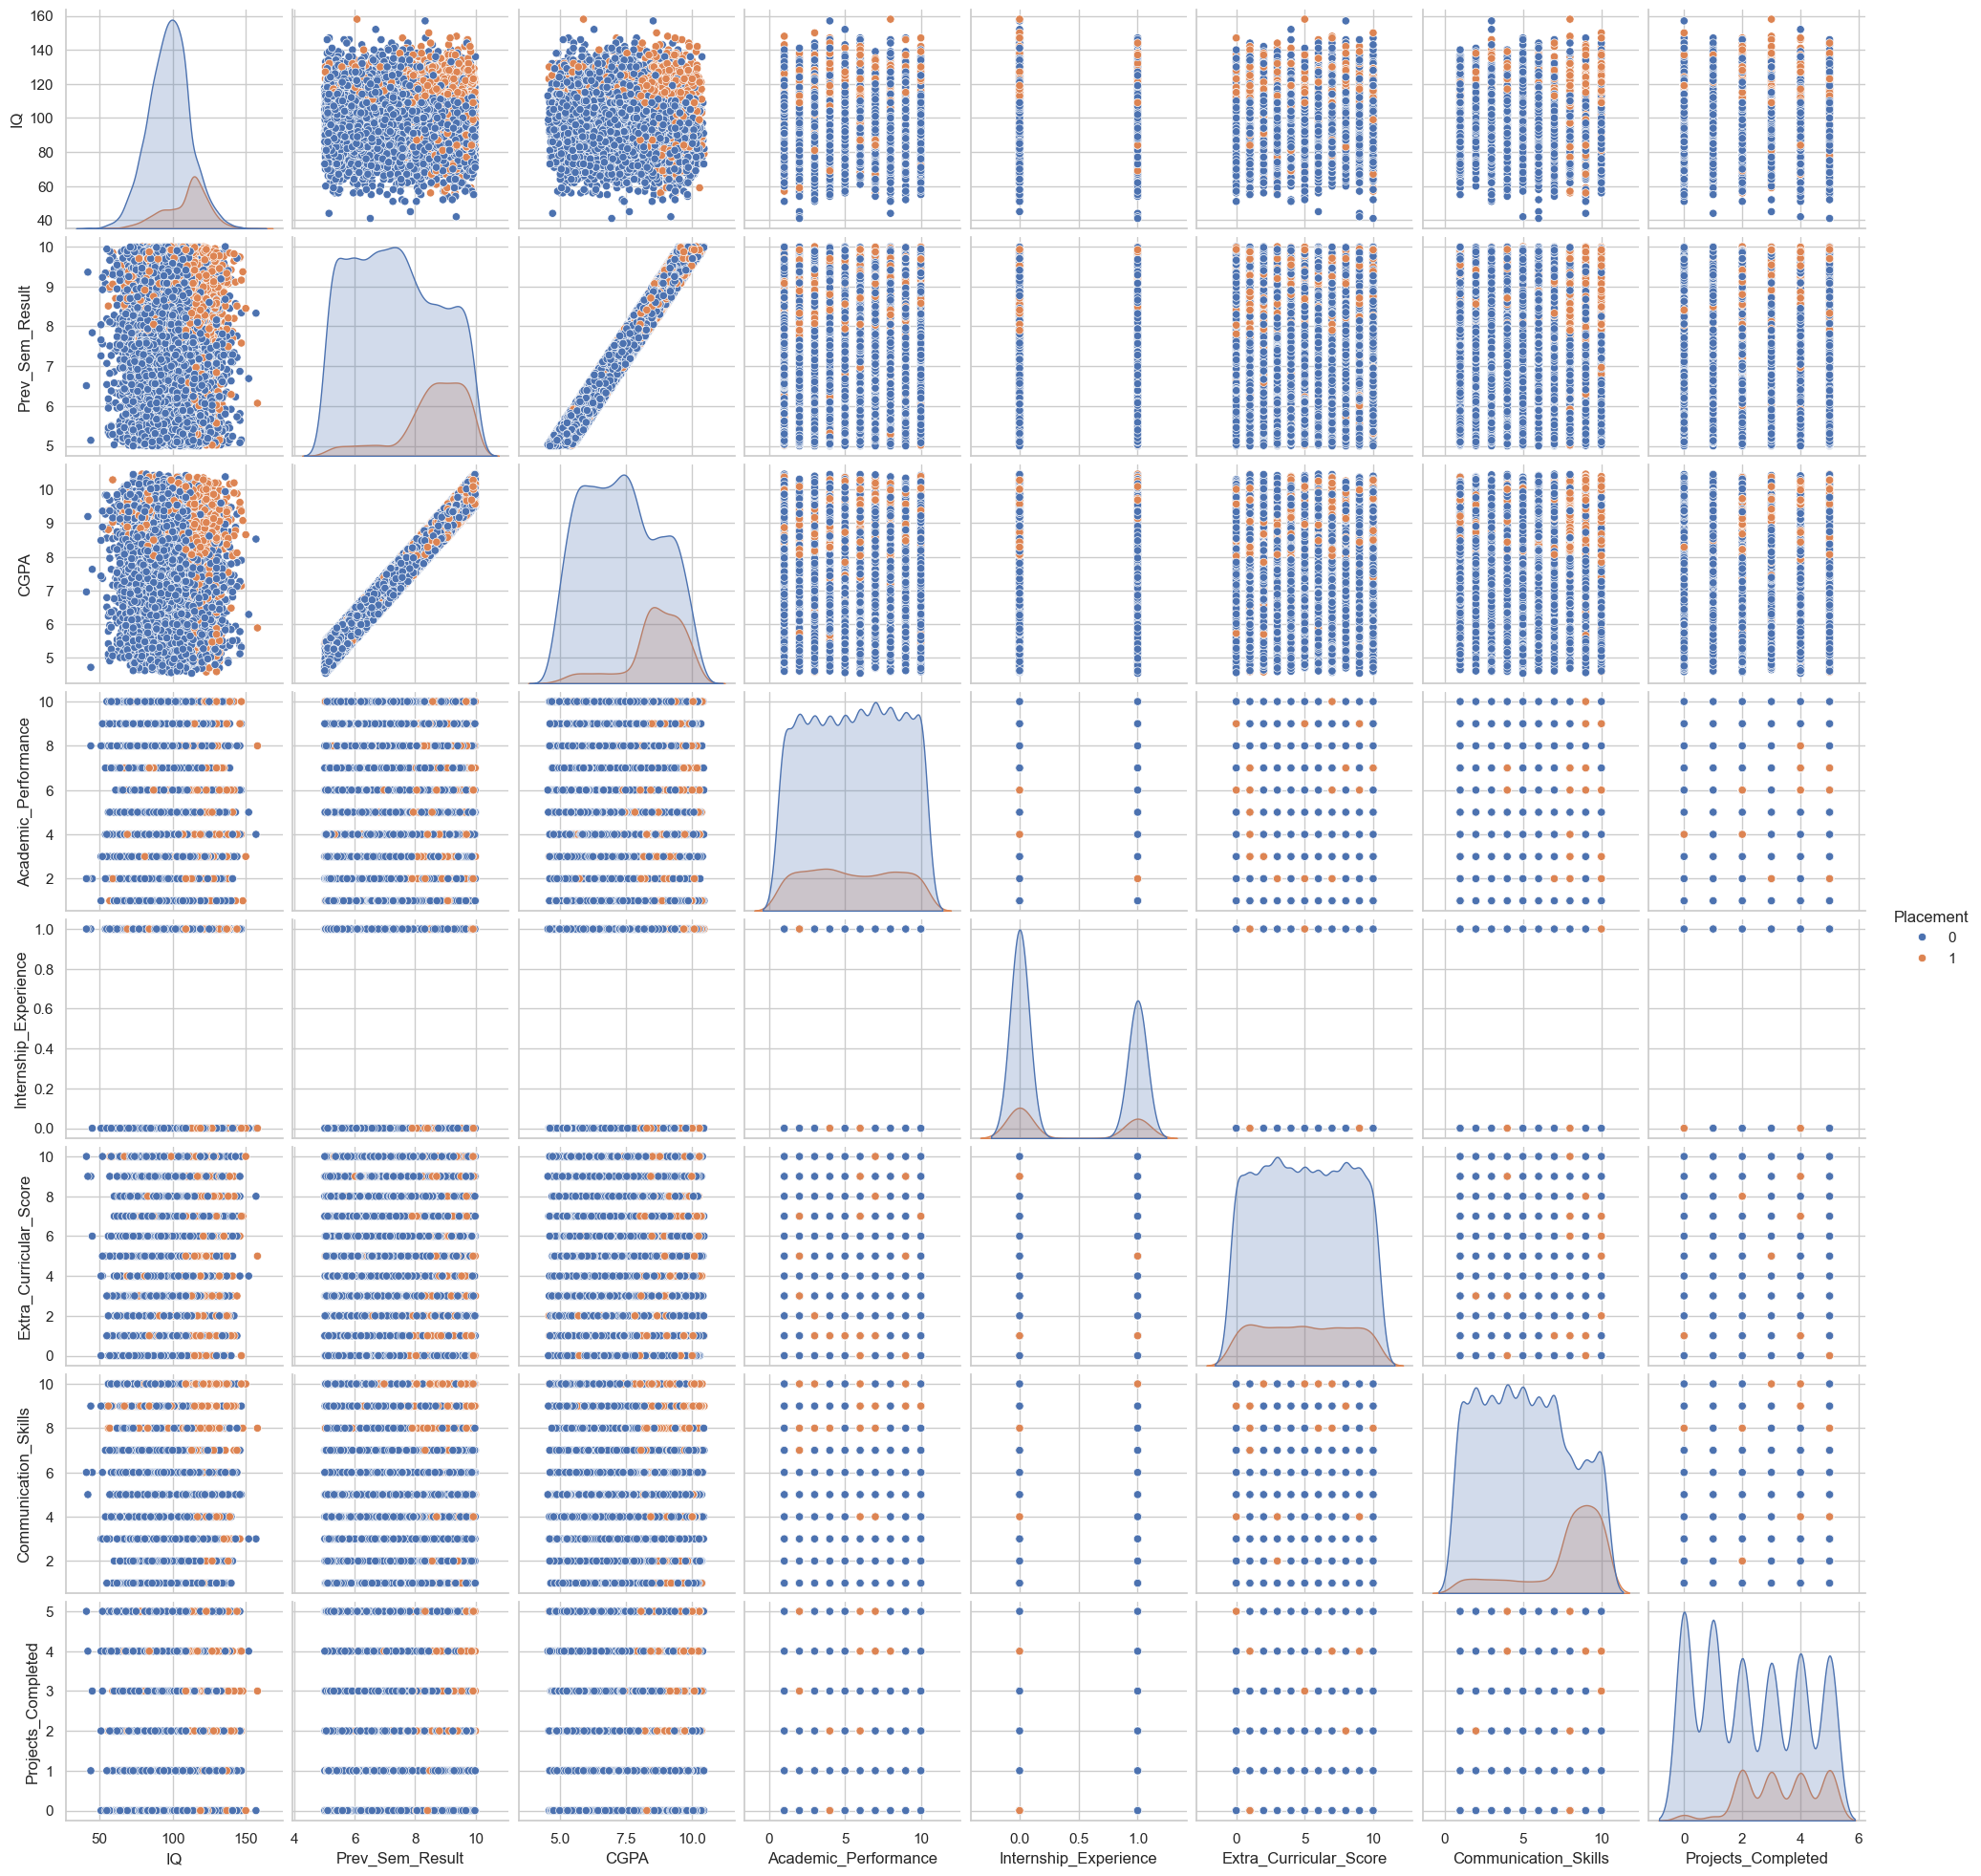

In [14]:
# Use sns.pariplot to visualize.
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot to visualize relationships between features, colored by Placement
sns.pairplot(df, hue='Placement')
plt.show()



## Feature Selection 

Choose the columns corresponding to the features _IQ_ and _internship experience_ to be your `X`. Target _placement_ as your `y`.

In [17]:
# Set X to the desired features.
X = df[['IQ', 'Internship_Experience']]

# Set y to be our target variable. 

y = df['Placement']



## Split to Testing and Training Datasets 

In [18]:
# Split our data into testing and training pairs.
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (default test_size=0.25, random_state optional)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


# Print the length and width of our testing data.
print('X_train: %d rows, %d columns' % X_train.shape)
print('X_test: %d rows, %d columns' % X_test.shape)
print('y_train: %d rows, 1 column' % y_train.shape)
print('y_test: %d rows, 1 column' % y_test.shape)

X_train: 7500 rows, 2 columns
X_test: 2500 rows, 2 columns
y_train: 7500 rows, 1 column
y_test: 2500 rows, 1 column


## Build and train your model

Initialize an empty Logistic Regression model, and then fit your model to your training data. 

In [19]:
# Initalize our logistic regressionmodel.
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
logreg = LogisticRegression()

# Fit the model to the training data
logreg.fit(X_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Evaluation

Make predictions with your test data and save the predictions as `y_pred`.

In [20]:
# 1. Make predictions of your test data and save them as `y_pred`. 

y_pred = logreg.predict(X_test)

y_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(2500,))

Calculate and print the accuracy, precision, recall, and F1 scores of your model.

In [22]:
# 2. Calculate and print the accuracy, precision, recall, and F1 scores of your model.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy Score: %f" % accuracy)
print("Precision Score: %f" % precision)
print("Recall Score: %f" % recall)
print('F1 Score: %f' % f1)

Accuracy Score: 0.833200
Precision Score: 0.303030
Recall Score: 0.024752
F1 Score: 0.045767


Plot a confusion matrix of your predicted results.

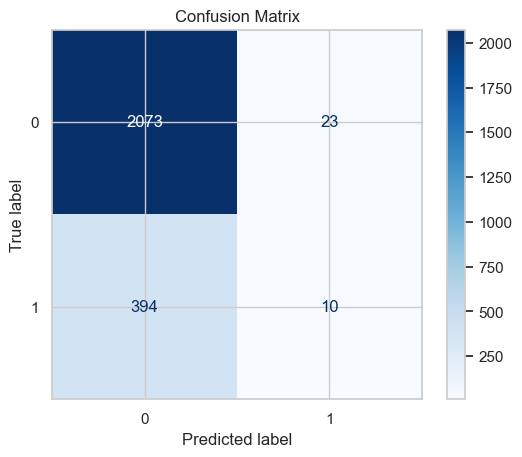

In [23]:
# 3. Plot a confusion matrix of your predicted results.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


How many true positives and true negatives did your model get?

In [25]:
# How many true positives and true negatives did your model get?
# Get confusion matrix values
cm = confusion_matrix(y_test, y_pred)
true_negatives = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives = cm[1, 1]

print('True Negatives: %d' % true_negatives)
print('True Positives: %d' % true_positives)

True Negatives: 2073
True Positives: 10


Such awful 😞

# What is the Most Important Feature
 
Use `statsmodel` to create a summary report. Interpret the results.

In [26]:
# Add a constant term to the independent variables.
import statsmodels.api as sm

# Assuming X and y are already defined and preprocessed (excluding target column, handling categorical data)
# Add a constant to the feature matrix X for the intercept
X_const = sm.add_constant(X)

# Fit the logistic regression model using statsmodels
model_sm = sm.Logit(y, X_const)
result = model_sm.fit()

# Print the model summary
print(result.summary())



Optimization terminated successfully.
         Current function value: 0.406531
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Placement   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Tue, 28 Oct 2025   Pseudo R-squ.:                 0.09524
Time:                        12:08:37   Log-Likelihood:                -4065.3
converged:                       True   LL-Null:                       -4493.3
Covariance Type:            nonrobust   LLR p-value:                1.408e-186
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -7.4077      0.224    -33.142      0.000      -7.846      -6.

# Extra Credit: Use your brain and make a better model (as in better scores).



In [ ]:
# Define the new X variable, and reuse the same y variable from before.


# Split our data into testing and training. Remember to use the same random state as you used before


# Initalize our model.


# Fit-train our model using our training data.


# Make new predicitions using our testing data. 


# Print each of our scores to inspect performance.


# Plot the confusion matrix.
